## Zadanie: Ogólny algorytm Hebbowski (GHA)


Zaimplementuj sieć jednowarstwową realizującą rozkład na czynniki główne za pomocą ogólnego algorytmu hebbowsiego (GHA). W implementacji możesz wykorzytsać szablon klasy ``GHA`` umieszczony w pliku [gha.py](gha.py).

**Parametry początkowe** (ustawiane w argumentach konstruktora):
* $N$ liczba epok
* $k$ liczba neuronów (komponentów)
* $\eta$ wspólczynnik uczenia

**Algorytm uczenia GHA** (realizowany w metodzie `fit(X)`)  

1. Zainicjuj macierz wag $\mathbf{W}$ 
2. Powtarzaj $N$ razy:
3. <ul>Dla każdego przypadku $\mathbf{x}$ ze zbioru uczącego wykonaj</ul>
4. <ul><ul> wyznacz aktywacje <br> $\mathbf{y} = \mathbf{W}\mathbf{x}$ </ul></ul>
5. <ul><ul>zaktualizuj wagi <br> $\Delta \mathbf{W}=\eta \left(\mathbf{y} \cdot \mathbf{x}^T-\mathrm{LT}\left[\mathbf{y} \cdot \mathbf{y}^T\right] \mathbf{W}\right)$ </ul></ul>
gdzie operacja $\mathbf{a}\cdot \mathbf{b}^T$ oznacza iloczyn zewnętrzny, a funkcja $\mathrm{LT}[\mathbf{A}]$ zeruje wszystkie elementy macierzy $\mathbf{A}$ znajdujące się powyżej diagonali

Przydatne funkcje:
* iloczyn zewnętrzny można wyznaczyć za pomocą funkcji [numpy.outer(a,b)](https://numpy.org/doc/stable/reference/generated/numpy.outer.html),
* funkcja [numpy.tril(x)](https://numpy.org/doc/stable/reference/generated/numpy.tril.html) zeruje wartości powyżej diagonali macierzy.

Wykorzystaj algorytm GHA do wyznaczenia $k$ czynników głównych dla danych MNIST. W celu skrócenia czasu uczenia wybierz do zbioru treningowego 1000 losowych przypadków ze zbioru cyfr.  
* zbuduj model uzywając $k$ neuronwów. Liczbę $k$ możesz dobrać dowolnie ale staraj się wybrać jak najmniejszą liczbę neuronów, która pozwoli później na odtworzenie danych z ,,dostatecznie wysoką jakością'' 
* przetransformuj dane treningowe do $k$ wymiarowej przestrzeni
* zrekonstruuj zbiór treningowy przez transformację odwrotną i zaprezentuj rekonstrukcję kilku przykładowych cyfr w postaci obrazów 28x28
* przedstaw wizualizację wektorów własnych cyfr (wagi $\mathbf{W}$ w postaci obrazów 28x28)
* przedstaw wykres rozrzutu prezentujący rozkład danych MNIST uzyskany po rzutowaniu dla dwóch pierwszych składowych głównych. Wyróżnij klasy różnymi kolorami. 

Dane MNIST zawierają 70K obrazków cyfr o wymiarach 28x28 (784 pikseli) i można je zaimportować w następujący sposób
```python
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', data_home='./dane/', parser='auto')
X = mnist.data.values
target = mnist.target.values
```

Rozwiązanie w postaci notatnika Jupyter (``.ipynb``) lub skrypt w języku Python (``.py``) umieść w repozytorium GitHub.

In [192]:
from sklearn.datasets import fetch_openml
import numpy as np

mnist = fetch_openml('mnist_784', data_home='./dane/', parser='auto')

n = 1000   # wybieramy 1000 przypadków
ind = np.random.default_rng(seed=42).permutation(mnist.data.shape[0])

X = mnist.data.values[ind[:n]]
target = mnist.target.values[ind[:n]]
w, h = 28, 28   # rozmiary obrazów

print('X.shape :', X.shape)
print('target: ', np.unique(target))

X.shape : (1000, 784)
target:  ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9']


### implementacja algorytmu

In [193]:
from gha import GHA
import numpy as np

class GHA2(GHA):
    def init(self, X):
        self.W = self.rng.normal(
            size=(self.n_components, X.shape[1]))

        return self
    
    def fit(self, X, seed=None):
        self.rng = np.random.default_rng(seed)
        self.init(X)
        self.weights = [ self.W.copy() ]

        for _ in range(self.n_epochs):
            for x in self.rng.permutation(X):
                y = self.transform(x)
                LT_W = np.tril(np.outer(y, y)) @ self.W
                dw = self.eta * (np.outer(y, x) - LT_W)
                self.W += dw
                
                self.weights.append(self.W.copy())

        return self

### normalizacja danych wejściowych

In [194]:
X_norm = X * 2 / 255.0 - 1.0
print(f'Min {X_norm.min()}, max {X_norm.max()}')

Min -1.0, max 1.0


### redukcja wymiarowości

In [229]:
n_components = 5
eta = 1e-4
n_epochs = 5

gha = GHA2(n_components=n_components, eta=eta, n_epochs=n_epochs)

gha.fit(X_norm)
X_norm_gha = gha.transform(X_norm)

print('Kształt zbioru danych przed transformacją:', X_norm.shape)
print('Kształt zbioru danych po transformacji:', X_norm_gha.shape)

Kształt zbioru danych przed transformacją: (1000, 784)
Kształt zbioru danych po transformacji: (1000, 5)


### rekonstrukcja cyfr

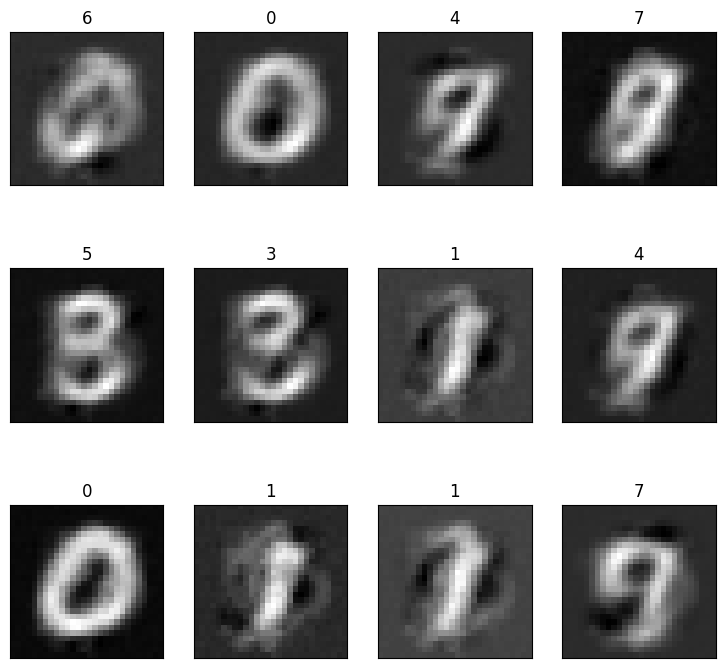

In [230]:
from utils import plot_gallery

X_norm_reconstructed = gha.inverse_transform(X_norm_gha)

plot_gallery(X_norm_reconstructed, h, w, target)

### wektory własne cyfr

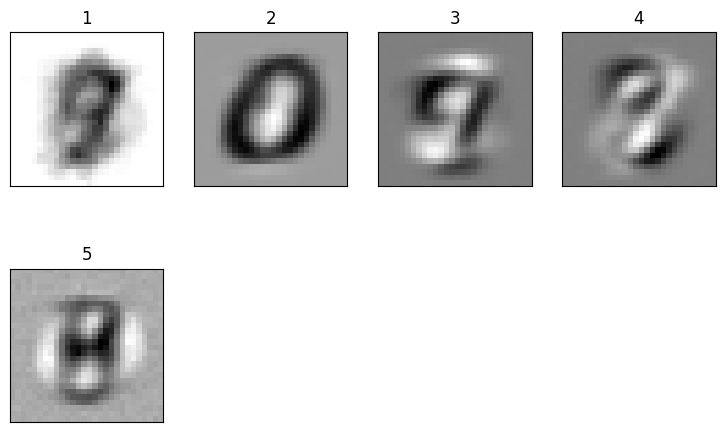

In [231]:
plot_gallery(gha.W, h, w)

### wykres rozrzutu

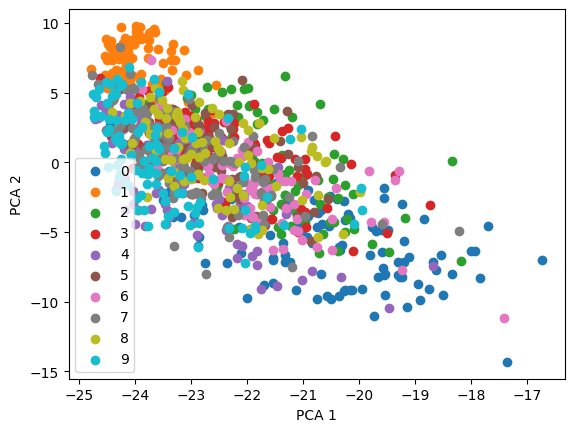

In [228]:
import matplotlib.pyplot as plt

for c in np.unique(target):
    plt.scatter(X_norm_gha[target==c, 0], X_norm_gha[target==c, 1], label=c)

plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend(loc='lower left')
plt.show()